## Random Forest Model on Personal Transaction Data
#### Aleksa Marie Ocampo
#### CS 549 Machine Learning Spring 2026

In [54]:
# data loading script with test splits
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape) 


train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)


In [55]:
# BASELINE MODEL:
# import random forest model
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
base_rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    random_state = 24
)

In [56]:
# training the model and making predictions
base_rf.fit(X_train, y_train)
y_pred_base = base_rf.predict(X_test)

Baseline Accuracy: 0.1452358926919519
              precision    recall  f1-score   support

           0       0.11      0.09      0.10        55
           1       0.09      0.06      0.08        77
           2       0.17      0.12      0.14        86
           3       0.22      0.32      0.26       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.05      0.03      0.04        35
           7       0.00      0.00      0.00         5
           8       0.05      0.05      0.05       130
           9       0.15      0.19      0.17       289
          10       0.04      0.02      0.03        44
          11       0.08      0.06      0.07        88
          12       0.13      0.11      0.12        66
          13       0.13      0.10      0.11        49
          14       0.08      0.08      0.08        49
          15       0.17      0.09      0.11        46
          16       0.08      0.05      0.06

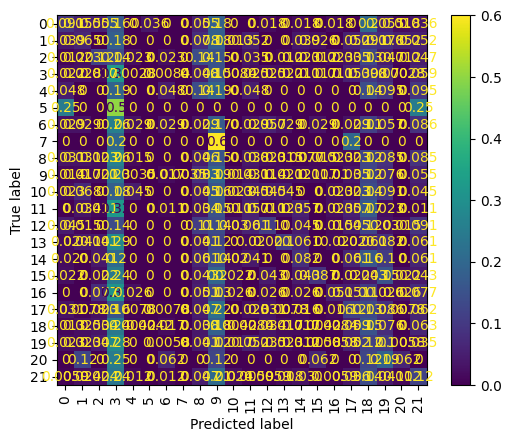

In [57]:
# BASELINE EVALUATION
# evaluate performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

cm = confusion_matrix(y_test, y_pred_base, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.show()

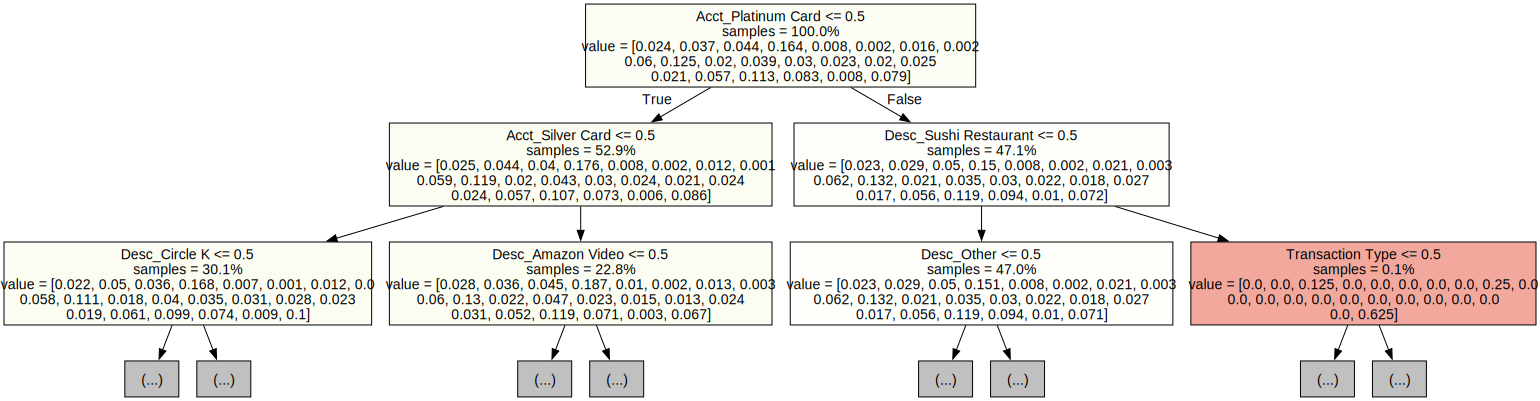

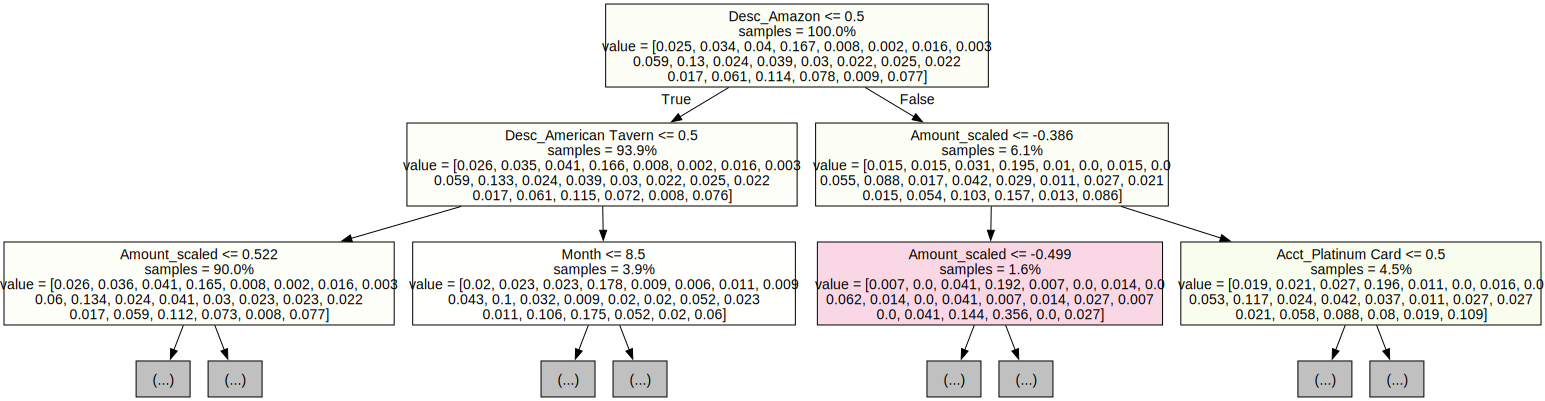

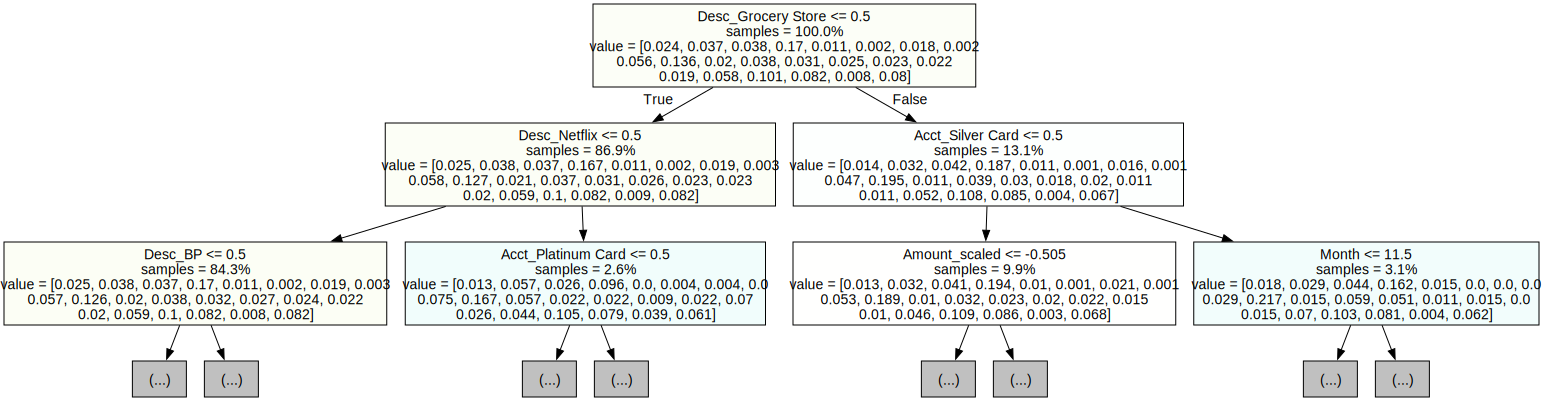

In [58]:
# result visualizations (tree visualization)
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# first 3 decision trees
for i in range(3):
    tree = base_rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [59]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1_macro", # use f1 instead of accuracy
    verbose=2,
    n_jobs=1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END class_weight=None, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=2

In [60]:
# final model evaluation
best_rf = search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned Accuracy: 0.1780758556891767
              precision    recall  f1-score   support

           0       0.36      0.09      0.14        55
           1       0.25      0.05      0.09        77
           2       0.26      0.08      0.12        86
           3       0.20      0.47      0.28       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.10      0.03      0.04        35
           7       0.00      0.00      0.00         5
           8       0.12      0.06      0.08       130
           9       0.16      0.27      0.20       289
          10       0.29      0.05      0.08        44
          11       0.13      0.05      0.07        88
          12       0.33      0.09      0.14        66
          13       0.31      0.10      0.15        49
          14       0.27      0.08      0.12        49
          15       0.60      0.07      0.12        46
          16       0.20      0.05      0.08   

/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


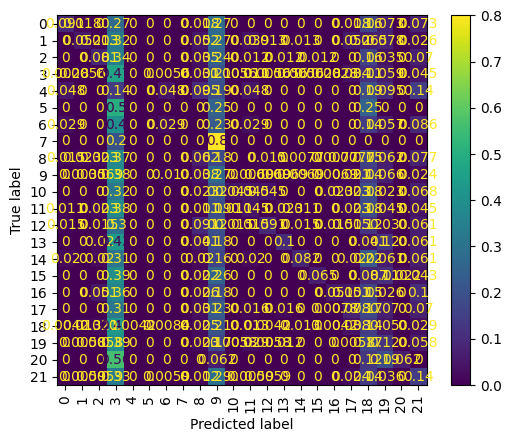

In [61]:
# final model confusion matrix
cm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.show()